In [1]:
# 모델 정의 할 때 , 레이어 지정하는 부분 다르니까 차이점 비교하면서 보자.

타겟
- class 0 -> 와인 종류 A
- class 1 -> 와인 종류 B
- class 2 -> 와인 종류 C

In [51]:
import  numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.src.utils import to_categorical
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
data = load_wine()
X = data.data
y = data.target


feature_names = data.feature_names # 특성 이름
df = pd.DataFrame(X, columns=feature_names) # 데이터 확인을 데이터 프레임으로 변환

df['target'] = y # 타겟 컬럼을 추가
print('전체 데이터 shape : ', df.shape)

전체 데이터 shape :  (178, 14)


In [53]:
from sklearn.model_selection import train_test_split

# 학습용/ 테스트용 데이터
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
# ======================================
# 3. 스케일링
# ======================================

# 값들의 평균 크기가 많이 차이나면.. 해줘야 함.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 학습 데이터 기준으로 평균과 표준편차를 학습하고 반환
X_test_scaled = scaler.transform(X_test) # 테스트 데이터는 학습 데이터 기준으로 반환

In [55]:
# ======================================
# 4. one-hot 인코드 수행
# ======================================
# ai가 신규 데이터 받아서 각 클래스 별로 확률값을 받아오게 되고, 그 결과를 종합해서 젤 큰 놈 1로 치환
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [56]:
# ======================================
# 5. 모델 정의
# ======================================
model = Sequential()
model.add(Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(3, activation='softmax'))

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
# ======================================
# 5. 모델 컴파일
# ======================================

# 손실함ㅂ수는 binary crossentropy, 평가지표는 accuracy 사용
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 롤백 정의
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [58]:
# ======================================
# 7. 모델 학습
# ======================================

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split= 0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2389 - loss: 1.3007 - val_accuracy: 0.3448 - val_loss: 1.1461
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5221 - loss: 1.0413 - val_accuracy: 0.6552 - val_loss: 0.9314
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6549 - loss: 0.8603 - val_accuracy: 0.8276 - val_loss: 0.7573
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7611 - loss: 0.7403 - val_accuracy: 0.9310 - val_loss: 0.6220
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8673 - loss: 0.5949 - val_accuracy: 0.9655 - val_loss: 0.5060
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8850 - loss: 0.5445 - val_accuracy: 1.0000 - val_loss: 0.4112
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8850 - loss: 0.4668 - val_accuracy: 1.0000 - val_loss: 0.3329
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9558 - loss: 0.3706 - val_accuracy: 1.0000 - val_loss:

In [61]:
# ======================================
# 7. 모델 평가
# ======================================

# 테스트 데이터에 대해 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

#평가 결과 출력
print('테스트 손실 : ', test_loss)
print('테스트 정확도 : ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 가장 확률이 높은 클래스를 선택 (softmax에 있는 기능)
y_pred = np.argmax(y_prob, axis=1)

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산 (분류모델이니까)
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print("정확도 : ", acc)
print()
print("confusion matrix : \n", cm)
print()
print('분류 리포트 : \n', classification_report(y_test, y_pred))

테스트 손실 :  0.033494625240564346
테스트 정확도 :  0.9722222089767456
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
정확도 :  0.9722222222222222

confusion matrix : 
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

분류 리포트 : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [62]:
import joblib

In [63]:
# ======================================
# 8. 학습 결과 저장
# ======================================

# 학습 결과 배포 이거를 계속 업데이트 하면서 배포하는 식.
DL_DATA_PATH = "./data/DL/"
model.save(DL_DATA_PATH + 'multiclass_model.h5') # .h5 로 저장했을 때 잘 되지 않으면 .keras 형식 파일로 저장 가능.

# 스케일러를 파일로 저장
joblib.dump(scaler, DL_DATA_PATH + 'multiclass_model_scaler.pkl')

# 학습 이력을 df 로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv 파일로 저장
history_df.to_csv(DL_DATA_PATH+"multiclass_model_history.csv",index=False)

# 저장 완료 메세지 출력
print("이진분류 모델, 스케일러, 학습이력 저장 완료")

이진분류 모델, 스케일러, 학습이력 저장 완료


In [64]:
import tensorflow as tf

In [65]:
# ======================================
# 9. 저장된 결과 읽어오기. (추론 쪽에서 하는 역할)
# ======================================
# 저장된 모델 다시 불러오기.
loaded_model = tf.keras.models.load_model(DL_DATA_PATH + 'multiclass_model.h5')

# 저장된 스케일러를 다시 불러오기
loaded_scaler = joblib.load(DL_DATA_PATH + 'multiclass_model_scaler.pkl')

In [93]:
# ======================================
# 10. 신규 데이터 예측
# ======================================

# 학습하지 않은 테스트데이터로 중 첫 5개를 신규 데이터로 예측 수행
new_data = X_test[:5]

# 학습데이터를 스케일링 처리 해줬기 때문에 테스트 데이터도 스케일링 해줘야 함.
new_data_scaled = loaded_scaler.transform(new_data)

# 신규데이터의 예측확률 계산.
new_prob = loaded_model.predict(new_data_scaled)
new_pred = np.argmax(new_prob, axis=1)


#결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률 : {new_prob[i][0]:.4f}, 예측 클래스 {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1번 샘플 - 예측확률 : 1.0000, 예측 클래스 0
2번 샘플 - 예측확률 : 0.0018, 예측 클래스 1
3번 샘플 - 예측확률 : 1.0000, 예측 클래스 0
4번 샘플 - 예측확률 : 0.2115, 예측 클래스 1
5번 샘플 - 예측확률 : 0.0019, 예측 클래스 1


In [94]:
new_pred

array([0, 1, 0, 1, 1])

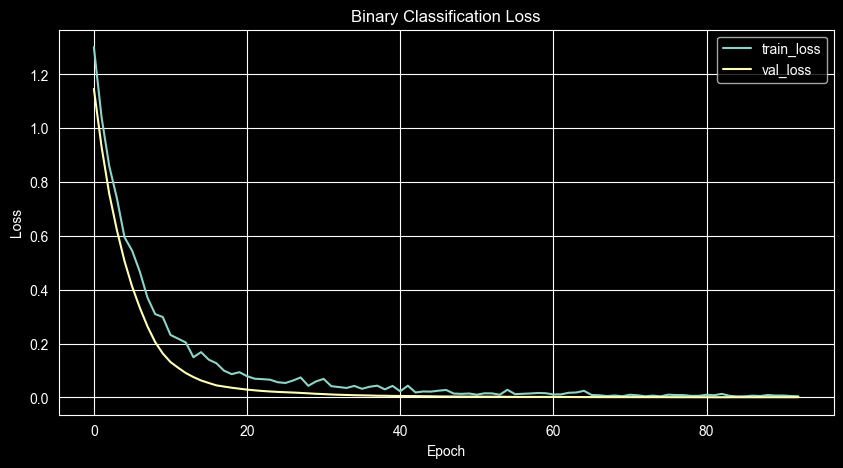

In [95]:
# ======================================
# 11. 시각화 결과 확인
# ======================================

# 학습결과 시각화
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title("Binary Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

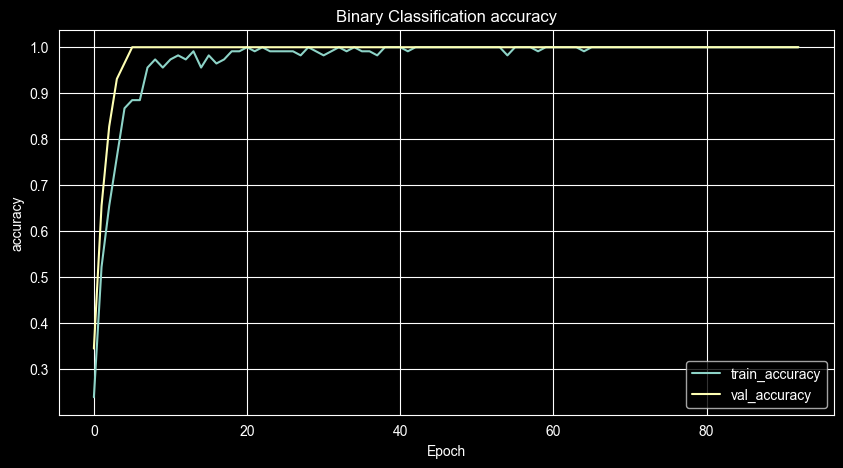

In [96]:
# 학습 정확도 시각화
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title("Binary Classification accuracy")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

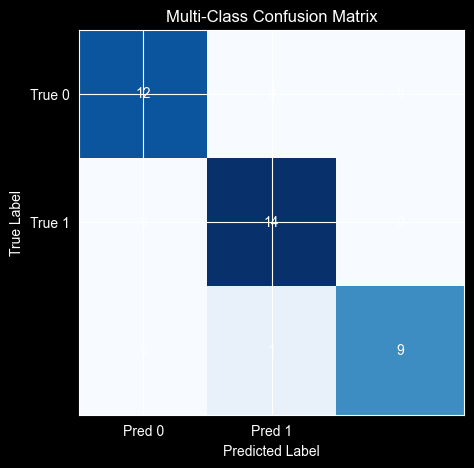

In [97]:
# confusion matrix 시각화
plt.figure(figsize=(10,5))
plt.imshow(cm, cmap="Blues")
plt.title("Multi-Class Confusion Matrix")

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# CM 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j], ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

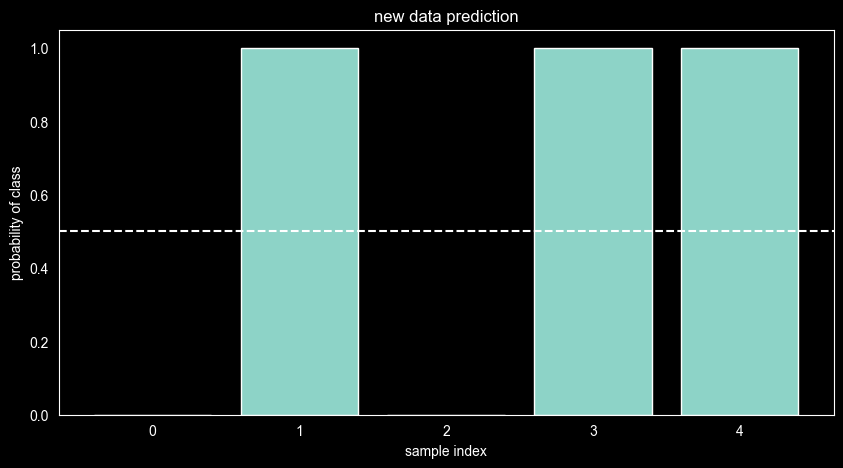

In [98]:
# 신규 데이터 예측 결과 시각화
# 신규데이터 예측 확률을 1차원 벡터 데이터로 만들어주고
# new_prob_flat = new_prob.flatten()
plt.figure(figsize=(10,5))
plt.bar(range(len(new_pred)), new_pred)

# 기준선 0.5로 표시
plt.axhline(0.5, linestyle='--')
plt.title("new data prediction")
plt.xlabel("sample index")
plt.ylabel("probability of class")
plt.grid()
plt.show()

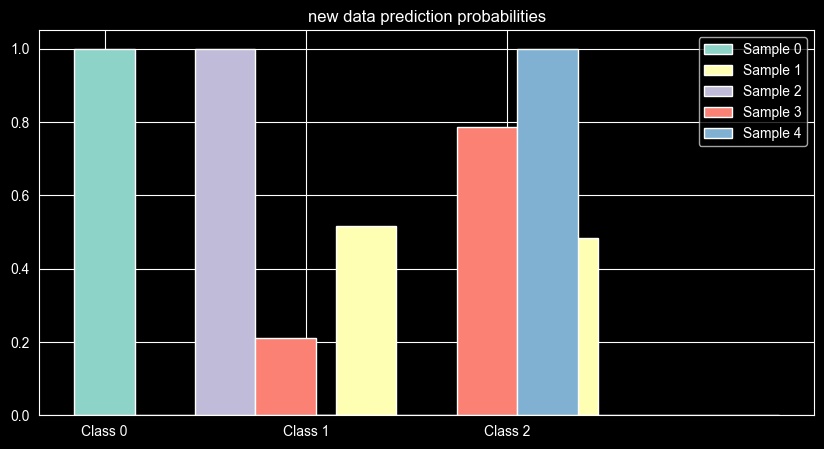

In [103]:
plt.figure(figsize=(10,5))
for i in range(len(new_prob)):
    plt.bar(
        np.arange(3) + i*0.3,
        new_prob[i],
        width =0.3,
        label = f"Sample {i}"
    )
plt.xticks([0,1,2], ['Class 0','Class 1','Class 2'])
plt.title('new data prediction probabilities')
plt.legend()
plt.show()


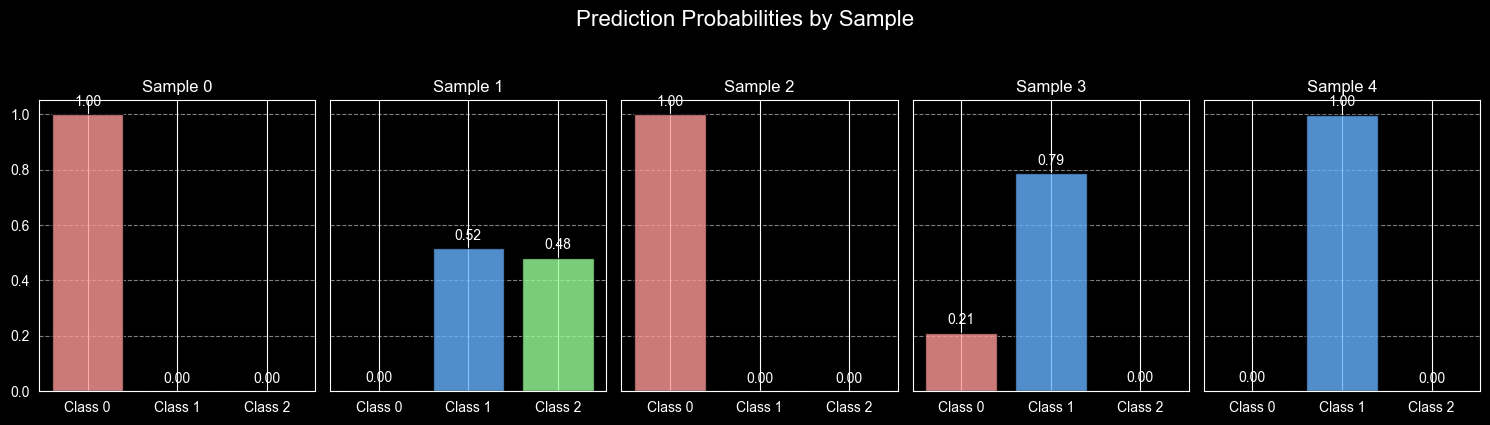

In [104]:

# sharey=True 를 주면 모든 그래프의 y축 눈금을 똑같이 맞춰줘서 비교하기 좋습니다.
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)

classes = ['Class 0', 'Class 1', 'Class 2']
colors = ['#FF9999', '#66B2FF', '#99FF99'] # 각 클래스별로 색상을 다르게 지정하면 더 예쁩니다.

# 5개의 샘플(new_prob)에 대해 반복해서 그립니다.
for i in range(len(new_prob)):
    ax = axes[i] # i번째 도화지 선택

    # 해당 도화지에 막대그래프 그리기
    bars = ax.bar(classes, new_prob[i], color=colors, edgecolor='black', alpha=0.8)

    ax.set_title(f"Sample {i}")
    ax.set_ylim(0, 1.05) # 확률이므로 y축은 0 ~ 1.05 로 고정
    ax.grid(axis='y', alpha=0.5, linestyle='--')

    # 💡 보너스 팁: 막대 위에 정확한 확률 숫자를 적어주면 가독성이 훨씬 올라갑니다.
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# 전체 그래프의 큰 제목 달기
plt.suptitle('Prediction Probabilities by Sample', fontsize=16, y=1.05)

# 그래프 간격 자동 조절
plt.tight_layout()
plt.show()